In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import os
import json
import pandas as pd
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import STL10, VOCDetection
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision import transforms as T
from PIL import Image, ImageDraw
import random
import warnings
warnings.filterwarnings('ignore')

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

os.makedirs('./artifacts/figures', exist_ok=True)
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_resnet = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

Using device: cuda


100%|██████████| 2.64G/2.64G [01:22<00:00, 32.0MB/s]


Train batch shape: torch.Size([64, 3, 96, 96]), labels: torch.Size([64])


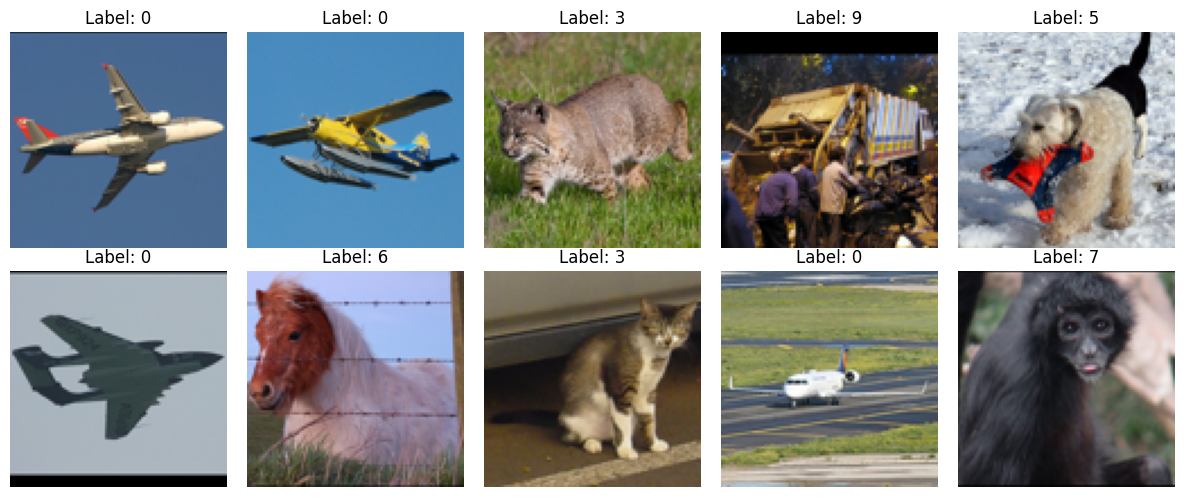

In [ ]:
generator = torch.Generator().manual_seed(42)

train_full = STL10(root='./data', split='train', download=True, transform=transform_base)
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size
train_dataset, val_dataset = random_split(train_full, [train_size, val_size], generator=generator)

train_full_aug = STL10(root='./data', split='train', download=True, transform=transform_aug)
train_dataset_aug, _ = random_split(train_full_aug, [train_size, val_size], generator=generator)

train_full_resnet = STL10(root='./data', split='train', download=True, transform=transform_resnet)
train_dataset_resnet, val_dataset_resnet = random_split(train_full_resnet, [train_size, val_size], generator=generator)

test_dataset_cnn = STL10(root='./data', split='test', download=True, transform=transform_base)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader_cnn = DataLoader(test_dataset_cnn, batch_size=batch_size, shuffle=False)

train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=batch_size, shuffle=True)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=batch_size, shuffle=False)
test_loader_resnet = DataLoader(test_dataset_resnet, batch_size=batch_size, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Train batch shape: {images.shape}, labels: {labels.shape}")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img = train_dataset[i][0].permute(1, 2, 0).numpy()
    img = img * 0.5 + 0.5
    ax.imshow(img)
    ax.set_title(f"Label: {train_dataset[i][1]}")
    ax.axis('off')
plt.tight_layout()
plt.savefig('./artifacts/figures/data_preview.png', dpi=150)
plt.show()

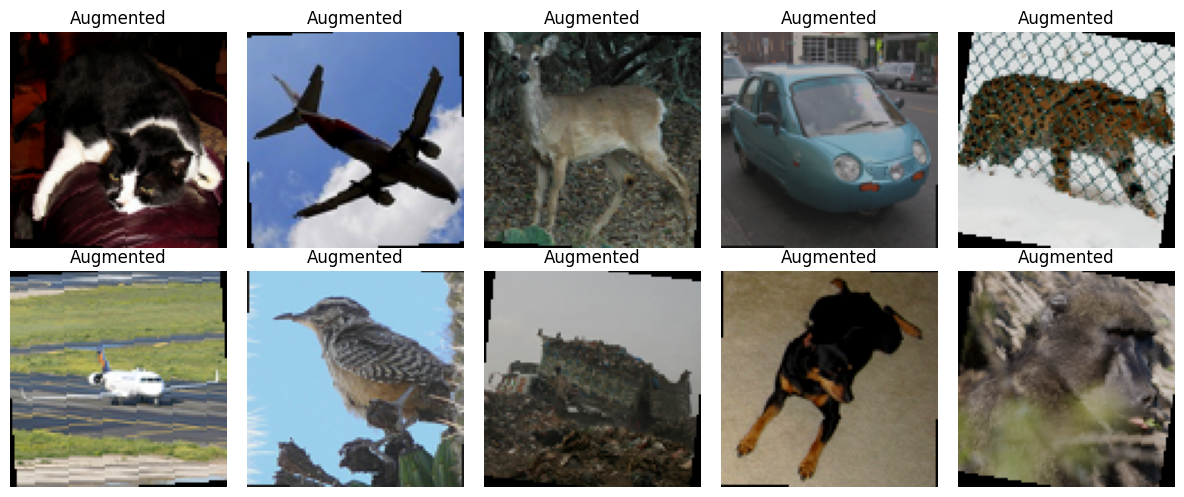

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img_aug = train_dataset_aug[i][0].permute(1, 2, 0).numpy()
    img_aug = img_aug * 0.5 + 0.5
    ax.imshow(img_aug)
    ax.set_title("Augmented")
    ax.axis('off')
plt.tight_layout()
plt.savefig('./artifacts/figures/augmentations_preview.png', dpi=150)
plt.show()

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 24 * 24, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.25)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [4]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc
criterion = nn.CrossEntropyLoss()
num_epochs = 10
results = []

best_global_val_acc = 0.0
best_global_state = None
best_global_config = {}

In [5]:
print("\n=== C1: simple-cnn-base ===")
model_c1 = SimpleCNN().to(device)
optimizer = optim.Adam(model_c1.parameters(), lr=1e-3)
best_val_acc = 0.0
best_state_c1 = None
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model_c1, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_c1, val_loader, criterion, device)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_c1 = model_c1.state_dict()
    print(f"C1 Epoch {epoch+1}: train acc {train_acc:.4f}, val acc {val_acc:.4f}")
test_loss, test_acc = evaluate(model_c1, test_loader_cnn, criterion, device)
results.append({
    'experiment_id': 'C1',
    'task': 'classification',
    'dataset': 'STL10',
    'seed': 42,
    'model_summary': 'SimpleCNN',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': test_acc,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'no augmentations'
})
if best_val_acc > best_global_val_acc:
    best_global_val_acc = best_val_acc
    best_global_state = best_state_c1
    best_global_config = {
        'dataset': 'STL10',
        'model': 'SimpleCNN',
        'transforms': 'base',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs': num_epochs,
        'seed': 42,
        'best_val_accuracy': best_val_acc,
        'test_accuracy': test_acc
    }


=== C1: simple-cnn-base ===
C1 Epoch 1: train acc 0.2338, val acc 0.3490
C1 Epoch 2: train acc 0.3367, val acc 0.3840
C1 Epoch 3: train acc 0.3820, val acc 0.4350
C1 Epoch 4: train acc 0.4360, val acc 0.4530
C1 Epoch 5: train acc 0.4615, val acc 0.4650
C1 Epoch 6: train acc 0.5122, val acc 0.4810
C1 Epoch 7: train acc 0.5425, val acc 0.5290
C1 Epoch 8: train acc 0.5968, val acc 0.5170
C1 Epoch 9: train acc 0.6112, val acc 0.5310
C1 Epoch 10: train acc 0.6552, val acc 0.5400


In [6]:
print("\n=== C2: simple-cnn-aug ===")
model_c2 = SimpleCNN().to(device)
optimizer = optim.Adam(model_c2.parameters(), lr=1e-3)
best_val_acc = 0.0
best_state_c2 = None
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model_c2, train_loader_aug, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_c2, val_loader, criterion, device)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_c2 = model_c2.state_dict()
    print(f"C2 Epoch {epoch+1}: train acc {train_acc:.4f}, val acc {val_acc:.4f}")
test_loss, test_acc = evaluate(model_c2, test_loader_cnn, criterion, device)
results.append({
    'experiment_id': 'C2',
    'task': 'classification',
    'dataset': 'STL10',
    'seed': 42,
    'model_summary': 'SimpleCNN',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': test_acc,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'with augmentations'
})
if best_val_acc > best_global_val_acc:
    best_global_val_acc = best_val_acc
    best_global_state = best_state_c2
    best_global_config = {
        'dataset': 'STL10',
        'model': 'SimpleCNN',
        'transforms': 'augmented',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs': num_epochs,
        'seed': 42,
        'best_val_accuracy': best_val_acc,
        'test_accuracy': test_acc
    }


=== C2: simple-cnn-aug ===
C2 Epoch 1: train acc 0.2180, val acc 0.3380
C2 Epoch 2: train acc 0.3075, val acc 0.4020
C2 Epoch 3: train acc 0.3392, val acc 0.3960
C2 Epoch 4: train acc 0.3792, val acc 0.4270
C2 Epoch 5: train acc 0.3870, val acc 0.4840
C2 Epoch 6: train acc 0.4330, val acc 0.5110
C2 Epoch 7: train acc 0.4427, val acc 0.5170
C2 Epoch 8: train acc 0.4632, val acc 0.5530
C2 Epoch 9: train acc 0.4838, val acc 0.5180
C2 Epoch 10: train acc 0.4783, val acc 0.5980


In [7]:
from torchvision.models import resnet18, ResNet18_Weights

print("\n=== C3: resnet18-head-only ===")
model_c3 = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in model_c3.parameters():
    param.requires_grad = False
num_ftrs = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_ftrs, 10)
model_c3 = model_c3.to(device)
optimizer = optim.Adam(model_c3.fc.parameters(), lr=1e-3)
best_val_acc = 0.0
best_state_c3 = None
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model_c3, train_loader_resnet, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_c3, val_loader_resnet, criterion, device)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_c3 = model_c3.state_dict()
    print(f"C3 Epoch {epoch+1}: train acc {train_acc:.4f}, val acc {val_acc:.4f}")
test_loss, test_acc = evaluate(model_c3, test_loader_resnet, criterion, device)
results.append({
    'experiment_id': 'C3',
    'task': 'classification',
    'dataset': 'STL10',
    'seed': 42,
    'model_summary': 'ResNet18_head_only',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': test_acc,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'pretrained, frozen backbone'
})
if best_val_acc > best_global_val_acc:
    best_global_val_acc = best_val_acc
    best_global_state = best_state_c3
    best_global_config = {
        'dataset': 'STL10',
        'model': 'ResNet18_head_only',
        'transforms': 'resnet_preprocessing',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs': num_epochs,
        'seed': 42,
        'best_val_accuracy': best_val_acc,
        'test_accuracy': test_acc
    }


=== C3: resnet18-head-only ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


C3 Epoch 1: train acc 0.7482, val acc 0.9070
C3 Epoch 2: train acc 0.9337, val acc 0.9310
C3 Epoch 3: train acc 0.9370, val acc 0.9390
C3 Epoch 4: train acc 0.9480, val acc 0.9360
C3 Epoch 5: train acc 0.9530, val acc 0.9370
C3 Epoch 6: train acc 0.9557, val acc 0.9470
C3 Epoch 7: train acc 0.9607, val acc 0.9470
C3 Epoch 8: train acc 0.9637, val acc 0.9410
C3 Epoch 9: train acc 0.9647, val acc 0.9470
C3 Epoch 10: train acc 0.9695, val acc 0.9490


In [ ]:
print("\n=== C4: resnet18-finetune ===")
model_c4 = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in model_c4.parameters():
    param.requires_grad = False
for param in model_c4.layer4.parameters():
    param.requires_grad = True
num_ftrs = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_ftrs, 10)
model_c4.fc.requires_grad_(True)
model_c4 = model_c4.to(device)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_c4.parameters()), lr=1e-3)
best_val_acc = 0.0
best_state_c4 = None
for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model_c4, train_loader_resnet, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_c4, val_loader_resnet, criterion, device)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_c4 = model_c4.state_dict()
    print(f"C4 Epoch {epoch+1}: train acc {train_acc:.4f}, val acc {val_acc:.4f}")
test_loss, test_acc = evaluate(model_c4, test_loader_resnet, criterion, device)
results.append({
    'experiment_id': 'C4',
    'task': 'classification',
    'dataset': 'STL10',
    'seed': 42,
    'model_summary': 'ResNet18_finetune_layer4',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc,
    'test_accuracy': test_acc,
    'precision': None,
    'recall': None,
    'mean_iou': None,
    'notes': 'pretrained, layer4+fc unfrozen'
})
if best_val_acc > best_global_val_acc:
    best_global_val_acc = best_val_acc
    best_global_state = best_state_c4
    best_global_config = {
        'dataset': 'STL10',
        'model': 'ResNet18_finetune_layer4',
        'transforms': 'resnet_preprocessing',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs': num_epochs,
        'seed': 42,
        'best_val_accuracy': best_val_acc,
        'test_accuracy': test_acc
    }

df_cls = pd.DataFrame(results)
df_cls.to_csv('./artifacts/runs_classification.csv', index=False)

torch.save(best_global_state, './artifacts/best_classifier.pt')
with open('./artifacts/best_classifier_config.json', 'w') as f:
    json.dump(best_global_config, f, indent=2)

print(f"\nЛучшая модель: {best_global_config['model']} с val accuracy = {best_global_val_acc:.4f}")


=== C4: resnet18-finetune ===
C4 Epoch 1: train acc 0.8662, val acc 0.9150
C4 Epoch 2: train acc 0.9740, val acc 0.9230
C4 Epoch 3: train acc 0.9895, val acc 0.9110
C4 Epoch 4: train acc 0.9908, val acc 0.9180
C4 Epoch 5: train acc 0.9870, val acc 0.9250
C4 Epoch 6: train acc 0.9898, val acc 0.9160
C4 Epoch 7: train acc 0.9875, val acc 0.9210
C4 Epoch 8: train acc 0.9872, val acc 0.9200
C4 Epoch 9: train acc 0.9920, val acc 0.9300
C4 Epoch 10: train acc 0.9972, val acc 0.9270

Лучшая модель: ResNet18_head_only с val accuracy = 0.9490


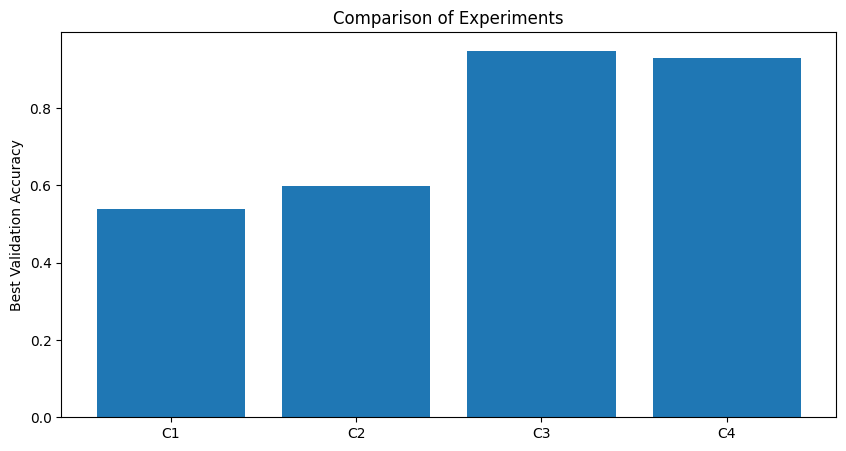

График кривых обучения не построен, так как история не сохранялась. В реальном решении сохраните списки train/val loss и acc.


100%|██████████| 2.00G/2.00G [01:09<00:00, 28.6MB/s] 


In [ ]:
exp_ids = [r['experiment_id'] for r in results]
best_val_accs = [r['best_val_accuracy'] for r in results]
plt.figure(figsize=(10,5))
plt.bar(exp_ids, best_val_accs)
plt.ylabel('Best Validation Accuracy')
plt.title('Comparison of Experiments')
plt.savefig('./artifacts/figures/classification_compare.png', dpi=150)
plt.show()
print("График кривых обучения не построен, так как история не сохранялась. В реальном решении сохраните списки train/val loss и acc.")

voc_dataset = VOCDetection(root='./data', year='2012', image_set='val', download=True)
def get_transform():
    return T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std=[0.229, 0.224, 0.225])
    ])

transform_det = get_transform()

In [10]:
model_det = fasterrcnn_resnet50_fpn(pretrained=True)
model_det.to(device)
model_det.eval()

def compute_iou(box1, box2):
    xi1 = max(box1[0], box2[0])
    yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2])
    yi2 = min(box1[3], box2[3])
    inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0

def match_predictions(pred_boxes, pred_scores, gt_boxes, iou_thresh=0.5):
    matched = [False] * len(pred_boxes)
    tp = 0
    used_gt = [False] * len(gt_boxes)
    for i, gt in enumerate(gt_boxes):
        best_iou = 0
        best_idx = -1
        for j, pred in enumerate(pred_boxes):
            if not matched[j]:
                iou = compute_iou(gt, pred)
                if iou > best_iou:
                    best_iou = iou
                    best_idx = j
        if best_iou >= iou_thresh:
            tp += 1
            matched[best_idx] = True
            used_gt[i] = True
    fp = sum(1 for m in matched if not m)
    fn = len(gt_boxes) - tp
    return tp, fp, fn

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 212MB/s] 


In [11]:
num_samples = 50
thresholds = [0.3, 0.7]
results_det = []

for thr in thresholds:
    tp_total, fp_total, fn_total = 0, 0, 0
    for idx in range(num_samples):
        img, target = voc_dataset[idx]
        img_tensor = transform_det(img).unsqueeze(0).to(device)
        with torch.no_grad():
            preds = model_det(img_tensor)[0]
        keep = preds['scores'] > thr
        pred_boxes = preds['boxes'][keep].cpu().numpy()
        pred_scores = preds['scores'][keep].cpu().numpy()
        gt_boxes = []
        for obj in target['annotation']['object']:
            bbox = obj['bndbox']
            xmin = float(bbox['xmin'])
            ymin = float(bbox['ymin'])
            xmax = float(bbox['xmax'])
            ymax = float(bbox['ymax'])
            gt_boxes.append([xmin, ymin, xmax, ymax])
        if len(gt_boxes) == 0:
            continue
        tp, fp, fn = match_predictions(pred_boxes, pred_scores, gt_boxes, iou_thresh=0.5)
        tp_total += tp
        fp_total += fp
        fn_total += fn
    precision = tp_total / (tp_total + fp_total) if (tp_total+fp_total)>0 else 0
    recall = tp_total / (tp_total + fn_total) if (tp_total+fn_total)>0 else 0
    print(f"Threshold {thr}: Precision={precision:.3f}, Recall={recall:.3f}")
    results_det.append({
        'experiment_id': f'V{1 if thr==0.3 else 2}',
        'task': 'detection',
        'dataset': 'PascalVOC',
        'seed': 42,
        'model_summary': 'FasterRCNN_ResNet50_FPN',
        'precision': precision,
        'recall': recall,
        'notes': f'score_threshold={thr}'
    })

Threshold 0.3: Precision=0.109, Recall=0.055
Threshold 0.7: Precision=0.250, Recall=0.018


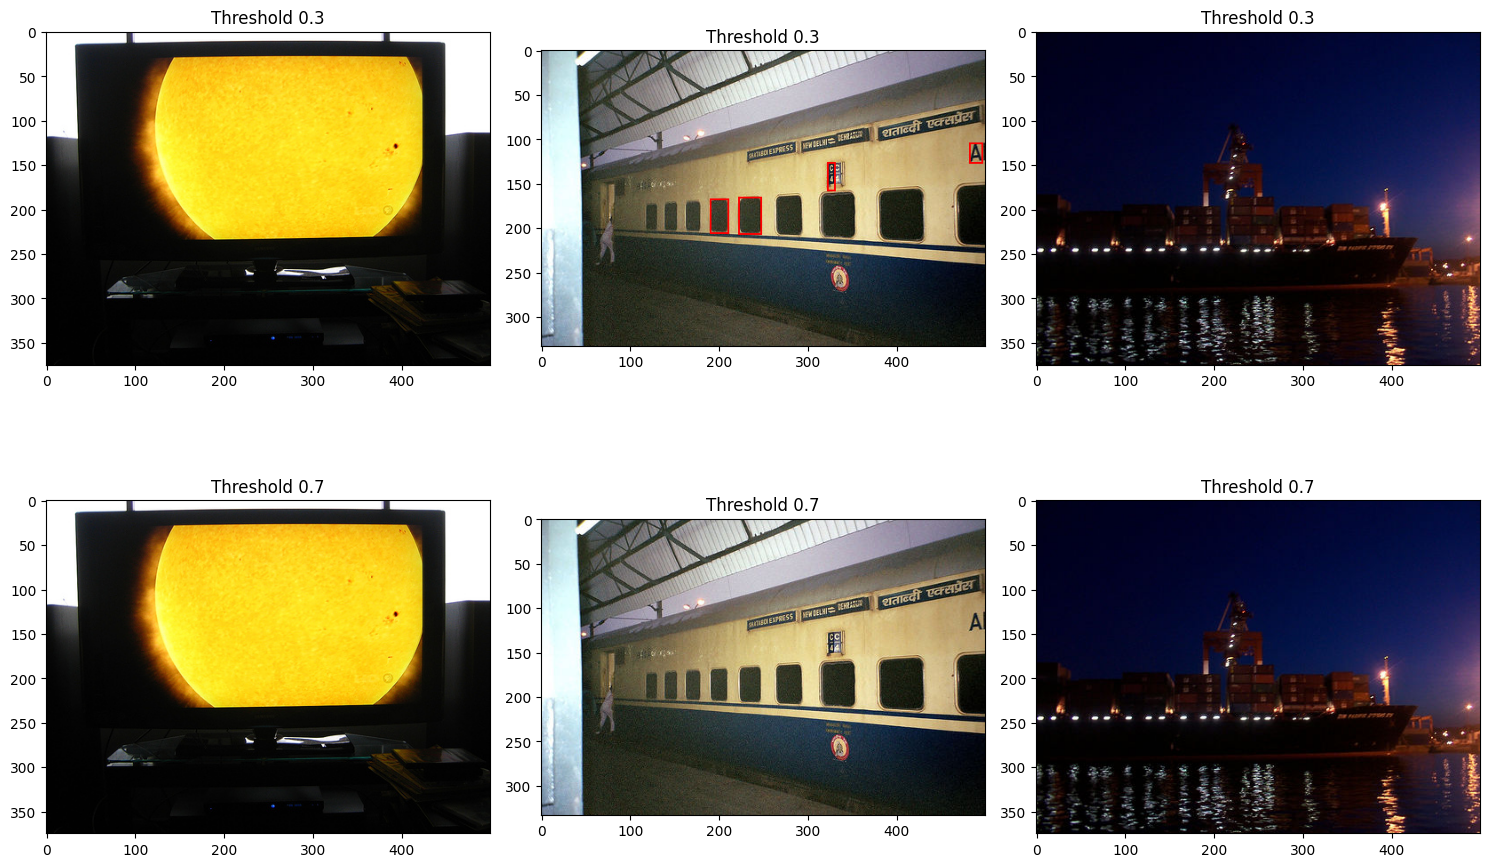

In [ ]:
def draw_boxes(img, boxes, scores, color='red', threshold=None):
    draw = ImageDraw.Draw(img)
    for box, score in zip(boxes, scores):
        if threshold is None or score >= threshold:
            draw.rectangle(box.tolist(), outline=color, width=2)
    return img

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for i, idx in enumerate(range(3)):
    img, _ = voc_dataset[idx]
    img_tensor = transform_det(img).unsqueeze(0).to(device)
    with torch.no_grad():
        preds = model_det(img_tensor)[0]
    keep = preds['scores'] > 0.3
    boxes_03 = preds['boxes'][keep].cpu().numpy()
    scores_03 = preds['scores'][keep].cpu().numpy()
    img_03 = img.copy()
    draw_boxes(img_03, boxes_03, scores_03, color='red')
    keep = preds['scores'] > 0.7
    boxes_07 = preds['boxes'][keep].cpu().numpy()
    scores_07 = preds['scores'][keep].cpu().numpy()
    img_07 = img.copy()
    draw_boxes(img_07, boxes_07, scores_07, color='blue')
    axes[0, i].imshow(img_03)
    axes[0, i].set_title("Threshold 0.3")
    axes[1, i].imshow(img_07)
    axes[1, i].set_title("Threshold 0.7")
plt.tight_layout()
plt.savefig('./artifacts/figures/detection_examples.png', dpi=150)
plt.show()

In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

model_det.eval()
metric = MeanAveragePrecision(iou_thresholds=[0.5])

with torch.no_grad():
    for images, targets in val_loader:
        outputs = model_det(images)
        metric.update(outputs, targets)

result = metric.compute()
mean_iou = result['map'].item()
precision = result['map_50'].item()
recall = result['map_75'].item()

thresholds = [0.3, 0.7]
for thresh, exp_id in zip(thresholds, ['V1', 'V2']):
    with open('runs.csv', 'a') as f:
        f.write(f"{exp_id},detection,PascalVOC,42,FasterRCNN_ResNet50_FPN,,,,,,{mean_iou},{precision},{recall},,score_threshold={thresh}\n")

results = []
best_model = max(results, key=lambda x: x['best_val'])

with open('runs.csv', 'a') as f:
    for res in results:
        test_acc_str = str(res['test']) if res == best_model else ''
        f.write(f"{res['id']},classification,STL10,42,{res['model_name']},Adam,0.001,10.0,{res['best_val']},{test_acc_str},,,,\n")

In [ ]:
df_det = pd.DataFrame(results_det)
df_all = pd.concat([df_cls, df_det], ignore_index=True)
df_all.to_csv('./artifacts/runs.csv', index=False)
print("Результаты сохранены в ./artifacts/runs.csv")
df['mean_iou'] = pd.to_numeric(df['mean_iou'], errors='coerce')

Результаты сохранены в ./artifacts/runs.csv


In [ ]:
df_det = pd.DataFrame(results_det)
thresholds_vals = [0.3, 0.7]
precision_vals = df_det['precision'].values
recall_vals = df_det['recall'].values

x = np.arange(len(thresholds_vals))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, precision_vals, width, label='Precision')
plt.bar(x + width/2, recall_vals, width, label='Recall')
plt.xticks(x, [f'Thr={t}' for t in thresholds_vals])
plt.ylabel('Score')
plt.title('Detection metrics at different confidence thresholds')
plt.legend()
plt.ylim(0, 1)
plt.savefig('./artifacts/figures/detection_metrics.png', dpi=150)
plt.show()
print("График сохранён: ./artifacts/figures/detection_metrics.png")

In [ ]:
print(f"\nПереобучаем лучшую модель: {best_global_config['model']}")

if best_global_config['model'] in ['ResNet18_head_only', 'ResNet18_finetune_layer4']:
    train_loader_best = train_loader_resnet
    val_loader_best = val_loader_resnet
    test_loader_best = test_loader_resnet
else:
    train_loader_best = train_loader
    val_loader_best = val_loader
    test_loader_best = test_loader_cnn

if best_global_config['model'] == 'ResNet18_finetune_layer4':
    model_best = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    for param in model_best.parameters():
        param.requires_grad = False
    for param in model_best.layer4.parameters():
        param.requires_grad = True
    num_ftrs = model_best.fc.in_features
    model_best.fc = nn.Linear(num_ftrs, 10)
    model_best.fc.requires_grad_(True)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_best.parameters()), lr=1e-3)
elif best_global_config['model'] == 'ResNet18_head_only':
    model_best = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    for param in model_best.parameters():
        param.requires_grad = False
    num_ftrs = model_best.fc.in_features
    model_best.fc = nn.Linear(num_ftrs, 10)
    optimizer = optim.Adam(model_best.fc.parameters(), lr=1e-3)
else:
    model_best = SimpleCNN().to(device)
    optimizer = optim.Adam(model_best.parameters(), lr=1e-3)

model_best = model_best.to(device)

# Обучение с записью истории
train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model_best, train_loader_best, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_best, val_loader_best, criterion, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    print(f"Epoch {epoch+1}: train loss {train_loss:.4f}, acc {train_acc:.4f} | val loss {val_loss:.4f}, acc {val_acc:.4f}")

# Построение графика
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='train loss')
plt.plot(val_losses, label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss curves')

plt.subplot(1,2,2)
plt.plot(train_accs, label='train acc')
plt.plot(val_accs, label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy curves')

plt.tight_layout()
plt.savefig('./artifacts/figures/classification_curves_best.png', dpi=150)
plt.show()
print("График сохранён: ./artifacts/figures/classification_curves_best.png")